<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/handling%20missing%20data2/mean_median_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

using pandas

In [105]:
df=pd.read_csv('/content/titanic_toy.csv')
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [106]:
df.isnull().mean()*100

,0
Age,19.865320
Fare,5.050505
Family,0.000000
Survived,0.000000


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [108]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [109]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [110]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [111]:
x_train.isnull().mean()*100

,0
Age,20.786517
Fare,5.056180
Family,0.000000


In [112]:
mean_age=x_train['Age'].mean()
median_age=x_train['Age'].median()

mean_fare=x_train['Fare'].mean()
median_fare=x_train['Fare'].median()

In [113]:
x_train['age_mean']=x_train['Age'].fillna(mean_age)
x_train['age_median']=x_train['Age'].fillna(median_age)

x_train['fare_mean']=x_train['Fare'].fillna(mean_age)
x_train['fare_median']=x_train['Fare'].fillna(median_age)

In [114]:
x_train.sample(5)

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
698,49.0,NaN,2,49.0,49.0,29.785904,28.750
85,33.0,15.850,3,33.0,33.0,15.850000,15.850
590,35.0,7.125,0,35.0,35.0,7.125000,7.125
279,35.0,20.250,2,35.0,35.0,20.250000,20.250
392,28.0,7.925,2,28.0,28.0,7.925000,7.925


In [115]:
print('original age variance',x_train['Age'].var())
print('age mean variance',x_train['age_mean'].var())
print('age median variance',x_train['age_median'].var())

print('original fare variance',x_train['Fare'].var())
print('fare mean variance',x_train['fare_mean'].var())
print('fare median variance',x_train['fare_median'].var())


original age variance 204.3495133904614
age mean variance 161.81262452718673
age median variance 161.9895663346054
original fare variance 2448.197913706318
fare mean variance 2324.623996772905
fare median variance 2324.9576136149317


plt.legend() in Matplotlib is used to display a legend box on the plot, which shows the labels of different plotted elements (lines, bars, etc.) for easy identification.

How It Works
When you plot something (e.g., with plt.plot, sns.kdeplot, etc.) and pass a label argument, calling plt.legend() will display those labels in a legend box.

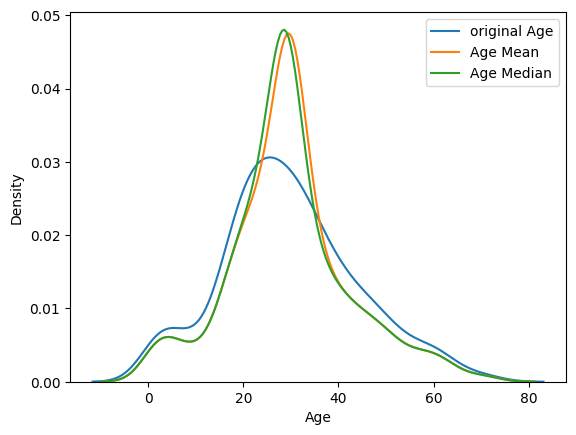

In [116]:
sns.kdeplot(x_train['Age'], label='original Age')
sns.kdeplot(x_train['age_mean'], label='Age Mean')
sns.kdeplot(x_train['age_median'], label='Age Median')
plt.legend()
plt.show()

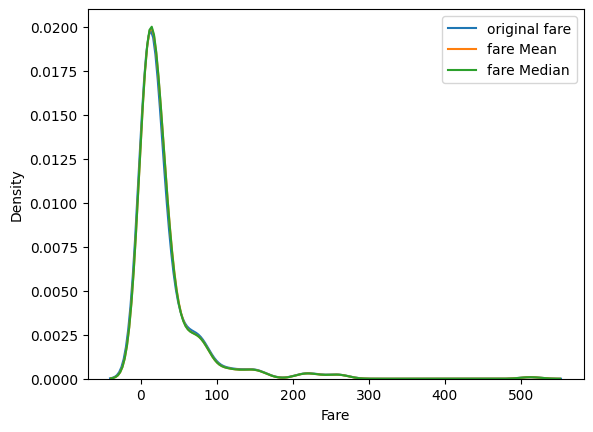

In [117]:
sns.kdeplot(x_train['Fare'], label='original fare')
sns.kdeplot(x_train['fare_mean'], label='fare Mean')
sns.kdeplot(x_train['fare_median'], label='fare Median')
plt.legend()
plt.show()

In [118]:
x_train.cov()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.383530,66.280487
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.399278,16.404484
age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.565299,52.483705
age_median,204.349513,57.957599,-5.112563,161.812625,161.989566,54.793876,54.710043
fare_mean,66.383530,2448.197914,16.399278,52.565299,54.793876,2324.623997,2324.765012
fare_median,66.280487,2448.197914,16.404484,52.483705,54.710043,2324.765012,2324.957614


In [119]:
x_train.corr()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.089754,0.089604
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205660,0.205710
age_mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.085707,0.085568
age_median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089292,0.089149
fare_mean,0.089754,1.000000,0.205660,0.085707,0.089292,1.000000,0.999989
fare_median,0.089604,1.000000,0.205710,0.085568,0.089149,0.999989,1.000000


<Axes: >

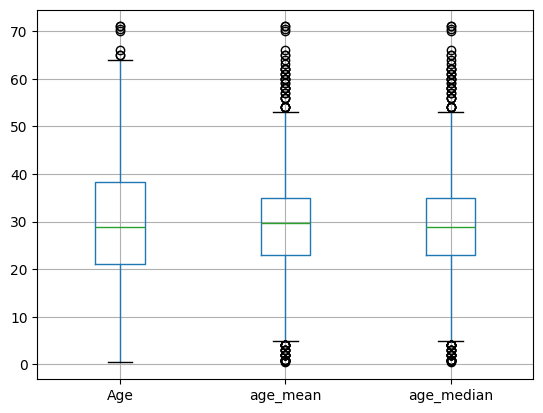

In [120]:
x_train[['Age','age_mean','age_median']].boxplot() #as you can see outlier increases in age_mean and age_median

<Axes: >

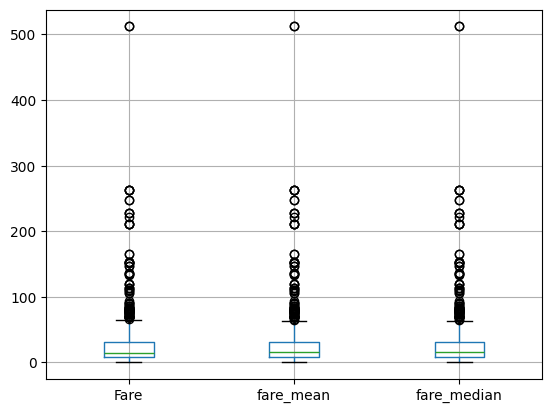

In [121]:
x_train[['Fare','fare_mean','fare_median']].boxplot() #as you can see outlier increases in fare_mean and fare_median

in conclusion as you can see for age column using mean and median for filling na causes huge change in cov,var,corr this because missing values are more in age.
but for fare no major change.

so, mean & median imputation for fare column can be considered

using sklearn


In [122]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [123]:
imputer1=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='median')

In [124]:
#age ke upar mean lagega
#fare ke upar median lagega
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [125]:
trf.fit(x_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(), ['Age']),
                                ('imputer2', SimpleImputer(strategy='median'),
                                 ['Fare'])])

In [126]:
trf.named_transformers_['imputer1'].statistics_

array([29.78590426])

In [127]:
trf.named_transformers_['imputer2'].statistics_

array([14.4583])

In [130]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [131]:
x_train

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 29.78590426, 221.7792    ,   0.        ],
       [ 29.78590426,  25.925     ,   0.        ]])